### Image Classification: Deteksi Jenis Sampah di Sekitar Kampus metode Transfer Learning

In [1]:
%pip install scipy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
%pip install tensorflow matplotlib numpy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

print("TensorFlow Version:", tf.__version__)
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

TensorFlow Version: 2.21.0
Num GPUs Available:  0


In [4]:
dataset_dir = "./"

# Dimensi standar input untuk arsitektur VGG16 adalah 224x224 piksel
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

In [5]:
# SEPARATE GENERATORS FOR TRAINING AND VALIDATION (ANTI-ERROR & AMAN)
# 1. Generator Khusus DATA TRAINING (Menggunakan Augmentasi Lengkap)
train_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.vgg16.preprocess_input, # Normalisasi VGG16
    rotation_range=20,         # Rotasi acak gambar
    width_shift_range=0.2,     # Pergeseran horizontal
    height_shift_range=0.2,    # Pergeseran vertikal
    shear_range=0.15,          # Peregangan sudut
    zoom_range=0.2,            # Zoom acak
    horizontal_flip=True,      # Membalik gambar secara horizontal
    fill_mode='nearest',
    validation_split=0.2       # Alokasi 20% untuk split data
)

# 2. Generator Khusus DATA VALIDATION (HANYA Normalisasi, TANPA Augmentasi)
val_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.vgg16.preprocess_input, # Wajib sama normalisasinya
    validation_split=0.2       # Harus menggunakan persentase split yang sama
)

# 3. Ambil data Training dari train_datagen
print("Loading Training Data (80%):")
train_generator = train_datagen.flow_from_directory(
    dataset_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',          # Mengambil porsi 80% training
    shuffle=True
)

# 4. Ambil data Validation dari val_datagen (Bersih dari augmentasi)
print("\nLoading Validation Data (20%):")
val_generator = val_datagen.flow_from_directory(
    dataset_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',        # Mengambil porsi 20% validasi
    shuffle=False               # Jangan di-shuffle agar evaluasi tidak acak
)

class_names = list(train_generator.class_indices.keys())
print("\n6 Kategori Sampah yang Terdeteksi:", class_names)

Loading Training Data (80%):
Found 2024 images belonging to 6 classes.

Loading Validation Data (20%):
Found 503 images belonging to 6 classes.

6 Kategori Sampah yang Terdeteksi: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [6]:
# Mengambil base model VGG16 tanpa lapisan klasifikasi atas (include_top=False)
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

# FREEZE LAYERS: Mengunci seluruh layer VGG16 agar bobot yang sudah terlatih tidak rusak
base_model.trainable = False

# Menambahkan Custom Classifier Head di atas Feature Extractor
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),       # Mereduksi matriks fitur menjadi vektor 1D
    Dense(256, activation='relu'),  # Fully Connected Layer untuk mempelajari pola baru sampah
    Dropout(0.5),                   # Regularisasi untuk mencegah Overfitting pada dataset kecil
    Dense(6, activation='softmax')  # Output layer untuk 6 kelas sampah
])

# Tampilkan ringkasan arsitektur jaringan terpadu
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,558 (56.64 MB)

 Trainable params: 132,870 (519.02 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [7]:
# COMPILING & TRAINING MODEL
# Menggunakan Fine-tuning parameter/Learning rate kecil agar konvergen stabil
model.compile(
    optimizer=Adam(learning_rate=0.0001), # Sesuai kaidah transfer learning: LR rendah
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Callback untuk menghentikan training secara otomatis jika val_loss tidak membaik dalam 4 epoch
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)

EPOCHS = 15

print("Memulai proses training model dengan Transfer Learning...")
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=[early_stop],
    verbose=1
)

Memulai proses training model dengan Transfer Learning...
Epoch 1/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 1355s 21s/step - accuracy: 0.2297 - loss: 4.1923 - val_accuracy: 0.4871 - val_loss: 1.5208
Epoch 2/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 1039s 16s/step - accuracy: 0.4190 - loss: 2.3011 - val_accuracy: 0.6123 - val_loss: 1.0798
Epoch 3/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 1234s 19s/step - accuracy: 0.4881 - loss: 1.7739 - val_accuracy: 0.6759 - val_loss: 0.8979
Epoch 4/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 1234s 19s/step - accuracy: 0.5534 - loss: 1.4328 - val_accuracy: 0.7097 - val_loss: 0.8254
Epoch 5/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 1125s 18s/step - accuracy: 0.5825 - loss: 1.2956 - val_accuracy: 0.7316 - val_loss: 0.7816
Epoch 6/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 995s 16s/step - accuracy: 0.6206 - loss: 1.1052 - val_accuracy: 0.7515 - val_loss: 0.7297
Epoch 7/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 1194s 19s/step - accuracy: 0.6428 - loss: 1.0446 - val_accuracy: 0.7435 - val_loss: 0.7032
Epoch 8/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 11

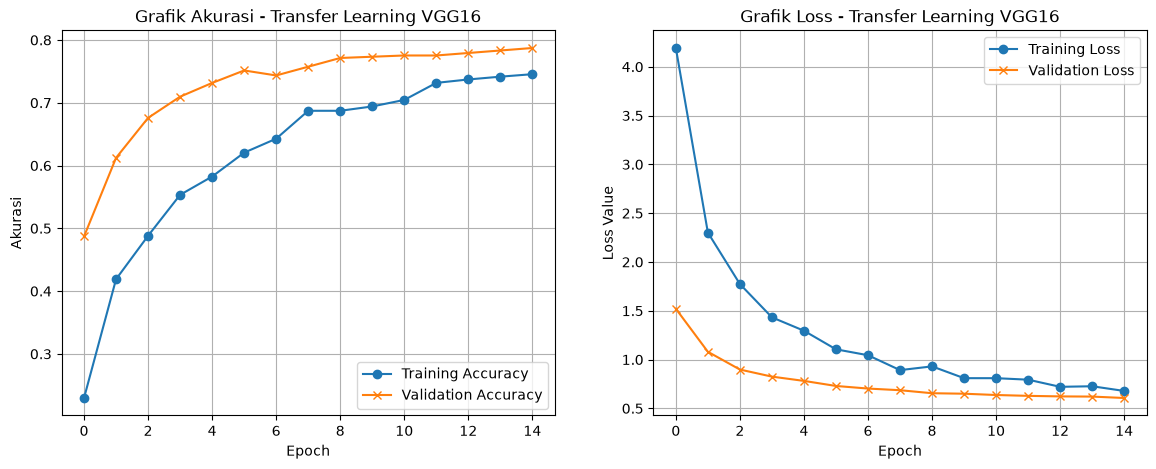

In [8]:
# VISUALISASI EVALUASI TRAINING (GRAFIK PERFORMA)
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(14, 5))

# Plotting Grafik Tren Akurasi
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', marker='o')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='x')
plt.legend(loc='lower right')
plt.title('Grafik Akurasi - Transfer Learning VGG16')
plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.grid(True)

# Plotting Grafik Tren Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', marker='o')
plt.plot(epochs_range, val_loss, label='Validation Loss', marker='x')
plt.legend(loc='upper right')
plt.title('Grafik Loss - Transfer Learning VGG16')
plt.xlabel('Epoch')
plt.ylabel('Loss Value')
plt.grid(True)

plt.show()

#### Kesimpulan
1. Model Tidak Overfitting, Nilai akurasi validasi (78.73%) yang sedikit lebih tinggi daripada akurasi training (74.56%) menandakan bahwa model  memiliki kemampuan generalisasi yang sangat baik. Hal ini berkat penerapan augmentasi yang kuat dan penggunaan layer Dropout(0.5).

2. Konvergensinya Bagus, Tren val_loss yang konsisten menyusut dari angka 1.5208 hingga menyentuh 0.6064 membuktikan bahwa pemilihan learning rate yang kecil (Adam(learning_rate=0.0001)) bekerja dengan sangat stabil dan optimal.